In [1]:
%pip install efficient_apriori matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from util import load_file
import time
import csv
from efficient_apriori import apriori
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path


In [3]:
def plot_graph(filepath, dataset_name):
    df = pd.read_csv(filepath)
    directory = Path(filepath).parent
    output_filename = f"{dataset_name}_plot.png"
    output_path = directory / output_filename
    plt.figure(figsize=(8, 5))
    plt.plot(df["min_support"], df["elapsed"], marker='o')
    plt.title(f"{dataset_name} dataset using Efficient-Apriori Package")
    plt.xlabel("Minimum Support")
    plt.ylabel("Runtime (seconds)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()

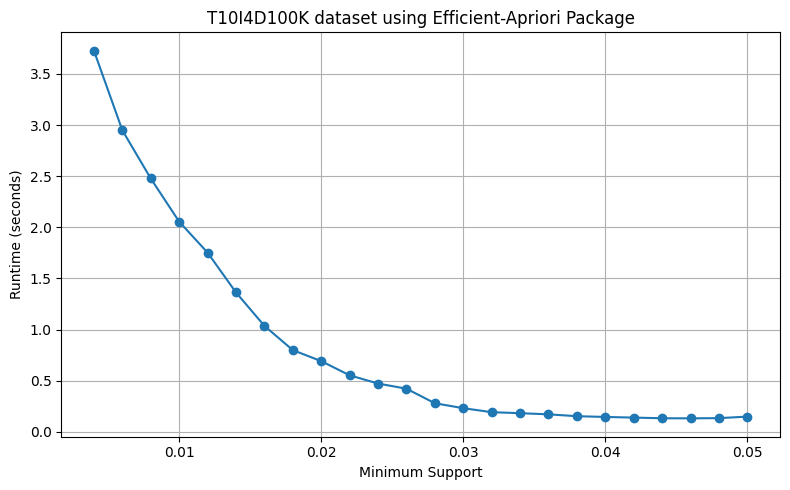

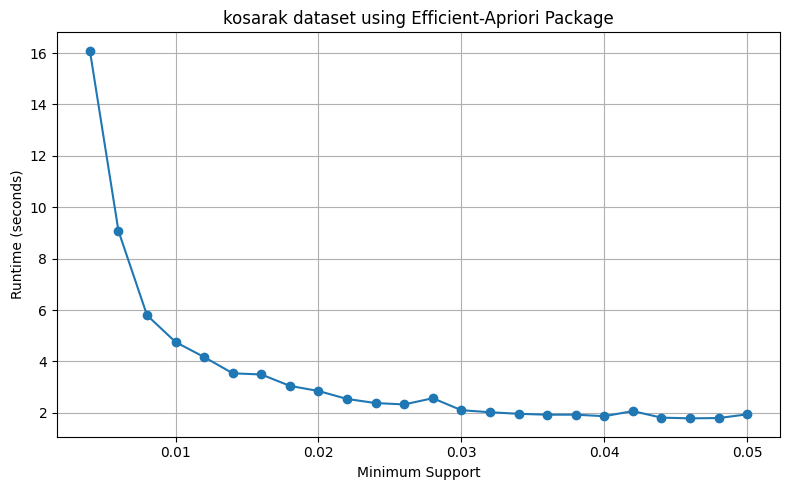

In [4]:
for filepath in ['T10I4D100K', 'kosarak']:
    transactions = load_file(filepath, None)
    with open(f"results/efficient_apriori/{filepath}.csv", 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        csv_writer.writerow(['min_support', 'elapsed'])
        for min_support in range(5000,200,-200):
            min_support/=100000
            start_time = time.time()
            frequent_item_sets, rules = apriori(transactions, min_support=min_support)
            end_time = time.time()
            elapsed = end_time - start_time
            csv_writer.writerow([min_support, elapsed])
            csv_file.flush()
    plot_graph(f"results/efficient_apriori/{filepath}.csv",filepath)